In [1]:
from copy import deepcopy
from functools import partial
from typing import Callable, Tuple

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.utils import tree_replace

In [2]:
SEED = 0
INPUT_DIM = 20
TARGET_NOISE = 0.1

In [14]:
def make_task():
    rng = jax.random.PRNGKey(SEED)
    return FeatureSiftingTask(n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=rng)


class LearnerState(eqx.Module):
    weights: jax.Array


@partial(jax.jit, static_argnames=('update_fn', 'steps'))
def run_train_loop(
    update_fn: Callable[[LearnerState, np.ndarray, np.ndarray], Tuple[LearnerState, np.ndarray]],
    learner_state: LearnerState,
    task: FeatureSiftingTask,
    steps: int,
):
    def _train_step(carry, _):
        learner_state, task, x, y = carry
        
        ### Forward pass ###
        pred = x @ learner_state.weights
        error = y - pred
        loss = error ** 2
        
        ### Update ###
        learner_state, prune_mask = update_fn(learner_state, x, y)
        
        ### New sample ###
        task, (x, y) = task.step(prune_mask)
        
        return (learner_state, task, x, y), {
            'losses': loss,
        }
    
    task, (x, y) = task.step(jnp.zeros(INPUT_DIM))
    learner_state, metrics = jax.lax.scan(
        _train_step,
        (learner_state, task, x, y),
        length = steps,
    )
    
    return metrics


def run_sweep(run_one, sweep_values, seeds):
    """Runs `run_one(value, seed)` for every pair: inner vmap over seeds, outer over swept values."""
    return jax.vmap(
        jax.vmap(run_one, in_axes=(None, 0)),  # seeds
        in_axes=(0, None),                     # swept values
    )(sweep_values, seeds)


def plot_learning_curves(metrics, sweep_values, sweep_name, log_freq=500):
    """Plots one learning curve per swept value, averaged over seeds."""
    def fmt(v):
        # Show powers of 2 or 10 as exponents (e.g. 0.01 -> 10^-2), else the plain value.
        # Compare in value-space so float32 imprecision (0.001 -> 0.00100000004) still matches.
        v = float(v)
        if v > 0:
            for base in (2, 10):
                exp = round(np.log(v) / np.log(base))
                if np.isclose(v, float(base) ** exp, rtol=1e-3):
                    return f'${base}^{{{exp}}}$'
        return f'{v:g}'

    losses = np.asarray(metrics['losses'])  # (n_values, n_seeds, steps, 1)
    n_values, n_seeds, steps = losses.shape[:3]
    curves = losses.reshape(n_values, n_seeds, -1, log_freq).mean(axis=(1, 3))
    steps_axis = np.arange(steps)[::log_freq]

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    for value, curve in zip(sweep_values, curves):
        plt.plot(steps_axis, curve, label=f'{sweep_name} = {fmt(value)}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
class LMSState(LearnerState):
    step_size: float

### Task init ###
task = make_task()

### Parameters ###
train_steps = 10000

### Hyperparameters ###
step_size = 0.01

### Network init ###
weights = np.zeros(INPUT_DIM)
algo_state = LMSState(weights, step_size)

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = np.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask

run_train_loop(lms_update, algo_state, task, train_steps)

{'losses': Array([[3.1623387 ],
        [0.00452587],
        [3.8105257 ],
        ...,
        [0.42613068],
        [0.9784223 ],
        [2.705481  ]], dtype=float32)}

In [5]:
class LMSState(LearnerState):
    step_size: float

### Task init ###
task = make_task()

### Parameters ###
train_steps = 10000

### Hyperparameters ###
step_size = 0.01

### Network init ###
weights = np.zeros(INPUT_DIM)
algo_state = LMSState(weights, step_size)

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = np.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask

run_train_loop(lms_update, algo_state, task, train_steps)

{'losses': Array([[3.1623387 ],
        [0.00452587],
        [3.8105257 ],
        ...,
        [0.42613068],
        [0.9784223 ],
        [2.705481  ]], dtype=float32)}

# V1: LMS

In [6]:
### Task init ###
task = make_task()
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 10000
log_freq = 500

### Network init ###
weights = np.zeros(INPUT_DIM)

lms_results = dict(
    losses = [],
)

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    lms_results['losses'].append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### New sample ###
    x, y = task.step(np.zeros(INPUT_DIM))
        

lms_results['binned_losses'] = np.array(lms_results['losses']).reshape(-1, log_freq)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.plot(np.arange(train_steps)[::log_freq], lms_results['binned_losses'].mean(axis=1))
plt.grid(True)
plt.show()



ValueError: matmul: Input operand 0 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

# V2: Simple Utility-Based Pruning

This is the simplest version of a utility-based pruning algorithm I can think of, that only introduces one more hyperparameter.

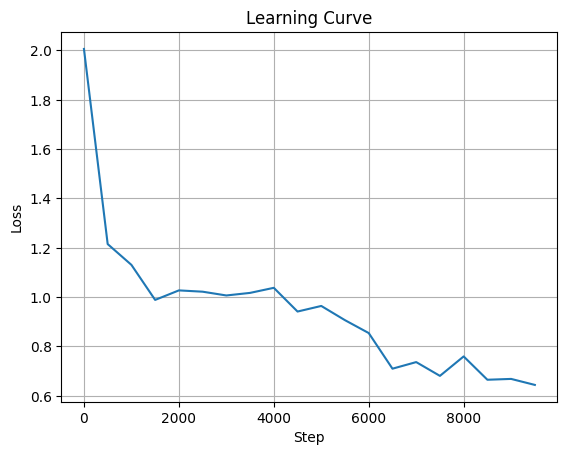

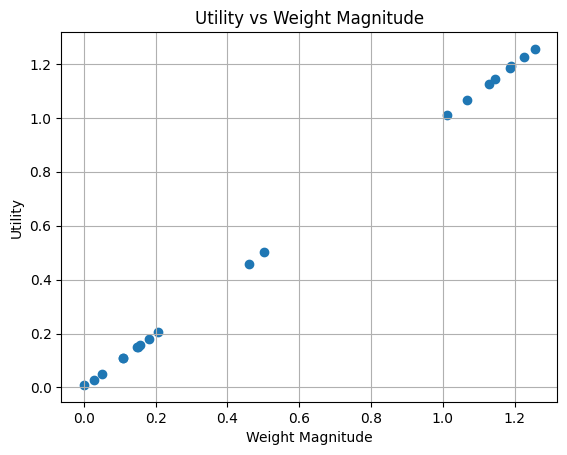

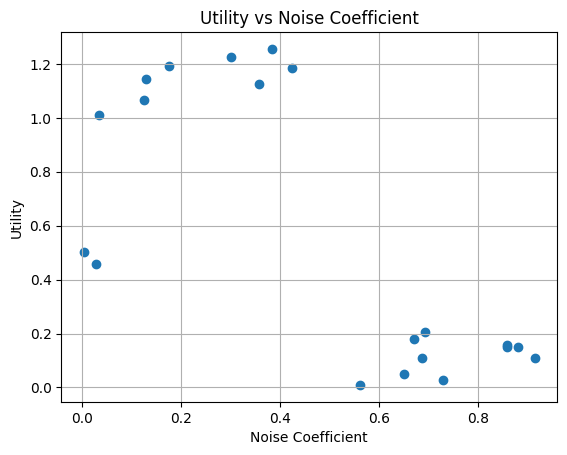

In [ ]:
### Task init ###
task = make_task()
x, y = task.step(np.zeros(INPUT_DIM))

### Problem Parameters ###
train_steps = 10000
log_freq = 500

### Hyperparameters ###
step_size = 0.01
prune_freq = 1000

### Network init ###
weights = np.zeros(INPUT_DIM)

v2_results = dict(
    losses = [],
)

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    v2_results['losses'].append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### Pruning ###
    prune_mask = np.zeros(INPUT_DIM)
    if (i + 1) % prune_freq == 0:
        utilities = np.abs(weights)
        lowest_idx = np.argmin(utilities)
        weights[lowest_idx] = 0
        prune_mask[lowest_idx] = 1
    
    ### New sample ###
    x, y = task.step(prune_mask)
        

v2_results['binned_losses'] = np.array(v2_results['losses']).reshape(-1, log_freq)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.plot(np.arange(train_steps)[::log_freq], v2_results['binned_losses'].mean(axis=1))
plt.grid(True)
plt.show()

plt.scatter(np.abs(weights), utilities)
plt.xlabel('Weight Magnitude')
plt.ylabel('Utility')
plt.title('Utility vs Weight Magnitude')
plt.grid(True)
plt.show()

plt.scatter(task.noise_coefficients, utilities)
plt.xlabel('Noise Coefficient')
plt.ylabel('Utility')
plt.title('Utility vs Noise Coefficient')
plt.grid(True)
plt.show()



# Vmapped Sweeps

Same flow as the sections above (define parameters → define the algorithm → run the training loop → plot). Each section sweeps **one** variable; two shared helpers in the setup cell keep the vmapping and plotting boilerplate out of each algorithm:

- **`run_sweep(run_one, sweep_values, seeds)`** wraps `run_one` in two levels of `vmap` — an inner one over seeds (averaged together) and an outer one over the swept values (one curve each) — returning metrics of shape `(n_values, n_seeds, train_steps, 1)`.
- **`plot_learning_curves(metrics, sweep_values, sweep_name)`** averages over the seed axis and plots one labeled learning curve per swept value. Values that are powers of 2 or 10 are shown as `2^k` / `10^k` in the legend.

So each algorithm below only defines its state, its update, and a small `run_one(value, seed)` that builds the task + algorithm and trains it — then sets `sweep_name` / `sweep_values` and calls the two helpers. We sweep 3 step sizes over 5 seeds for both V1 (LMS) and V2 (utility-based pruning).

## V1 (vmapped): LMS

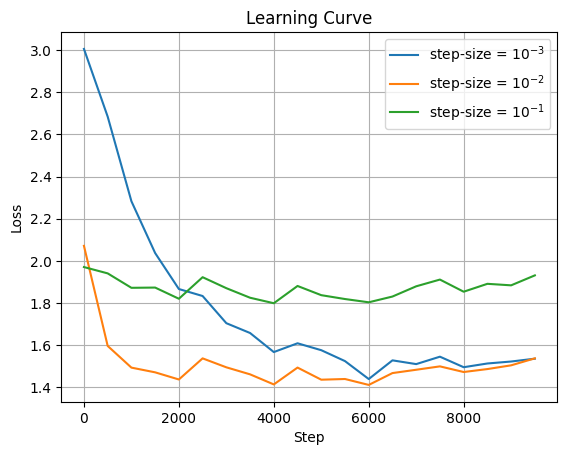

In [18]:
### Algorithm: LMS ###
class LMSState(LearnerState):
    step_size: float

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = jnp.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask

### Parameters ###
train_steps = 10000

### Sweep: one variable over 5 seeds ###
seeds = jnp.arange(5)
sweep_name = 'step-size'
sweep_values = jnp.array([0.001, 0.01, 0.1])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(step_size, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = LMSState(jnp.zeros(INPUT_DIM), step_size)
    return run_train_loop(lms_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)

## V2 (vmapped): Simple Utility-Based Pruning

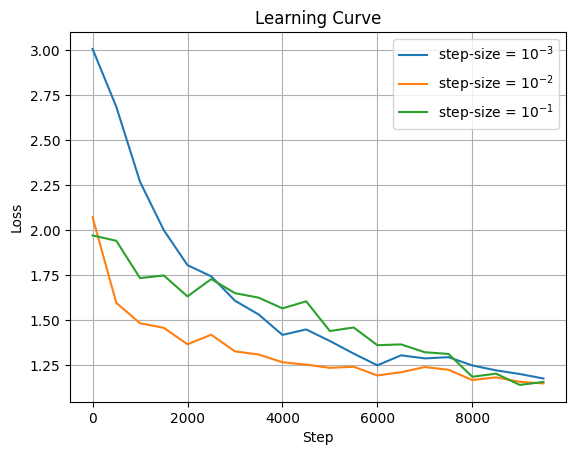

In [17]:
### Algorithm: utility-based pruning ###
class V2State(LearnerState):
    step_size: float
    prune_freq: int = eqx.field(static=True)
    step_idx: jax.Array

def v2_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    weights = learner_state.weights - learner_state.step_size * grad

    ### Pruning: every prune_freq steps, drop the lowest-utility feature ###
    step_idx = learner_state.step_idx + 1
    should_prune = (step_idx % learner_state.prune_freq) == 0
    utilities = jnp.abs(weights)
    prune_mask = should_prune * jax.nn.one_hot(jnp.argmin(utilities), INPUT_DIM)
    weights = jnp.where(prune_mask, 0.0, weights)

    new_state = tree_replace(learner_state, weights=weights, step_idx=step_idx)
    return new_state, prune_mask

### Parameters ###
train_steps = 10000

### Hyperparameters (fixed) ###
prune_freq = 1000

### Sweep: one variable over 5 seeds ###
seeds = jnp.arange(5)
sweep_name = 'step-size'
sweep_values = jnp.array([0.001, 0.01, 0.1])

### Build the task + algorithm for one swept value + seed, and train ###
def run_one(step_size, seed):
    task = FeatureSiftingTask(
        n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=jax.random.PRNGKey(seed),
    )
    algo_state = V2State(jnp.zeros(INPUT_DIM), step_size, prune_freq, jnp.array(0))
    return run_train_loop(v2_update, algo_state, task, train_steps)

metrics = run_sweep(run_one, sweep_values, seeds)
plot_learning_curves(metrics, sweep_values, sweep_name)